In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import hashlib

In [4]:
#Removing NaN and Anything outside of TX
eduData = pd.read_csv('/Users/ShavaughnDunson/Documents/Code/DFG/Education_Data.csv')
noNan = eduData.dropna()
isTX = noNan['NAME'].str.contains('Texas')
noNanTX = noNan[isTX]
isNotMO = ~noNanTX['NAME'].str.contains('Missouri|Oklahoma')
noNanTX = noNanTX[isNotMO]
#Removing non DFW Counties
northCounties = 'Dallas|Tarrant|Denton|Collin|Rockwall|Kaufman|Ellis|Johnson|Parker|Wise'
isNotNorth = noNanTX['NAME'].str.contains(northCounties)
noNanTXNorth = noNanTX[isNotNorth]
print(noNanTXNorth)
eduData = noNanTXNorth
eduData.to_csv('Education_Data.csv', index = False)

                   GEO_ID                                         NAME  \
0    1400000US48085030303    Census Tract 303.03; Collin County; Texas   
1    1400000US48085030702    Census Tract 307.02; Collin County; Texas   
2    1400000US48085030802    Census Tract 308.02; Collin County; Texas   
3    1400000US48085031003    Census Tract 310.03; Collin County; Texas   
4    1400000US48085031201    Census Tract 312.01; Collin County; Texas   
..                    ...                                          ...   
121  1400000US48439123302  Census Tract 1233.02; Tarrant County; Texas   
122  1400000US48439123700     Census Tract 1237; Tarrant County; Texas   
123  1400000US48497150403     Census Tract 1504.03; Wise County; Texas   
124  1400000US48497150603     Census Tract 1506.03; Wise County; Texas   
125  1400000US48497150607     Census Tract 1506.07; Wise County; Texas   

     S1501_C01_001E  S1501_C01_001M  S1501_C01_002E  S1501_C01_002M  \
0               616             213     

In [17]:
#Removing ** and -
eData = pd.read_csv('/Users/ShavaughnDunson/Documents/Code/DFG/Education_Data.csv')
noGood = eData[~eData.isin(['**', '-']).any(axis=1)]
eData = noGood
print(eData)
eData.to_csv('Education_Data.csv', index = False)

                    GEO_ID                                         NAME  \
10    1400000US48085030303    Census Tract 303.03; Collin County; Texas   
66    1400000US48085030702    Census Tract 307.02; Collin County; Texas   
68    1400000US48085030802    Census Tract 308.02; Collin County; Texas   
72    1400000US48085031003    Census Tract 310.03; Collin County; Texas   
79    1400000US48085031201    Census Tract 312.01; Collin County; Texas   
...                    ...                                          ...   
1663  1400000US48439123302  Census Tract 1233.02; Tarrant County; Texas   
1666  1400000US48439123700     Census Tract 1237; Tarrant County; Texas   
1675  1400000US48497150403     Census Tract 1504.03; Wise County; Texas   
1679  1400000US48497150603     Census Tract 1506.03; Wise County; Texas   
1683  1400000US48497150607     Census Tract 1506.07; Wise County; Texas   

      S1501_C01_001E  S1501_C01_001M  S1501_C01_002E  S1501_C01_002M  \
10               616       

In [11]:
#Removing all non-north tx
labData = pd.read_csv('/Users/ShavaughnDunson/Documents/Code/DFG/lacnty23.csv')
noNan = labData.dropna()
onlyTX = noNan['County Name/State Abbreviation'].str.contains('TX')
labData = noNan[onlyTX]
accTX = ~labData['County Name/State Abbreviation'].str.contains('MO|OH')
labData = labData[accTX]
onlyNorth = labData['County Name/State Abbreviation'].str.contains('Dallas|Tarrant|Denton|Collin|Rockwall|Kaufman|Ellis|Johnson|Parker|Wise')
labData = labData[onlyNorth]
removeWorth = ~labData['County Name/State Abbreviation'].str.contains('Collingsworth')
labData = labData[removeWorth]
print(labData)
labData.to_csv('lacnty23.csv', index = False)

         LAUS Code  State FIPS Code  County FIPS Code  \
0  CN4808500000000             48.0              85.0   
1  CN4811300000000             48.0             113.0   
2  CN4812100000000             48.0             121.0   
3  CN4813900000000             48.0             139.0   
4  CN4825100000000             48.0             251.0   
5  CN4825700000000             48.0             257.0   
6  CN4836700000000             48.0             367.0   
7  CN4839700000000             48.0             397.0   
8  CN4843900000000             48.0             439.0   
9  CN4849700000000             48.0             497.0   

  County Name/State Abbreviation    Year  Labor Force  Employed  Unemployed  \
0              Collin County, TX  2023.0       644705    622134       22571   
1              Dallas County, TX  2023.0      1461604   1405512       56092   
2              Denton County, TX  2023.0       568450    548549       19901   
3               Ellis County, TX  2023.0       106348   

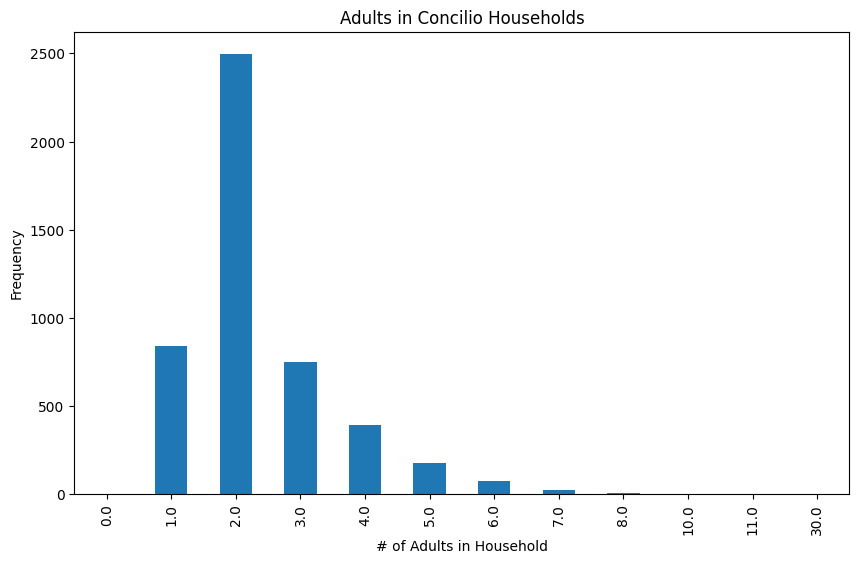

In [ ]:
#Concilio data
concData = pd.read_csv('/Users/ShavaughnDunson/Documents/Code/DFG/Concilio Raw Data.csv')
# Plotting the frequency of '# of Adults in Household'
frequency = concData['# of Adults in Household'].value_counts().sort_index()
frequency.plot(kind='bar', figsize=(10, 6), title='Adults in Concilio Households')
plt.xlabel('# of Adults per Household')
plt.ylabel('Frequency')
plt.show()

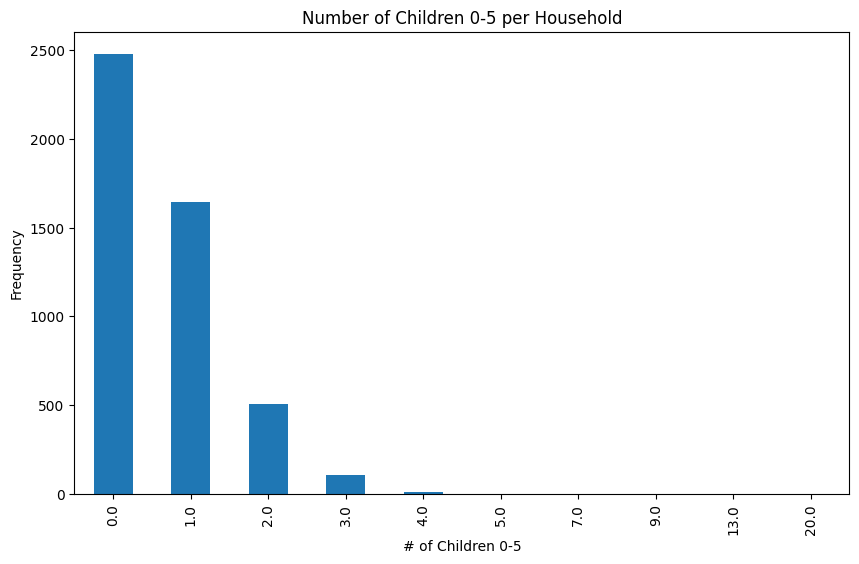

In [11]:
frequency = concData['# of Children 0-5'].value_counts().sort_index()
frequency.plot(kind='bar', figsize=(10, 6), title='Number of Children 0-5 per Household')
plt.xlabel('# of Children 0-5')
plt.ylabel('Frequency')
plt.show()

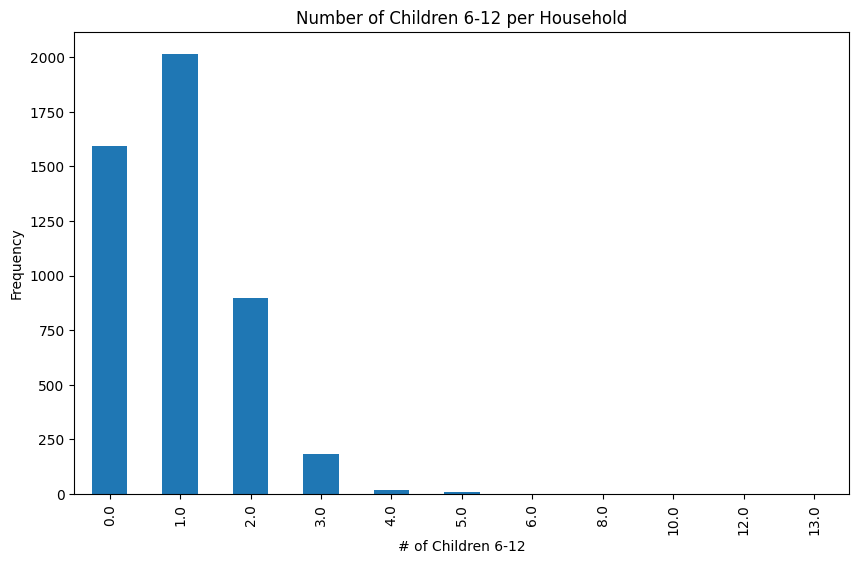

In [12]:
frequency = concData['# of Children 6-12'].value_counts().sort_index()
frequency.plot(kind='bar', figsize=(10, 6), title='Number of Children 6-12 per Household')
plt.xlabel('# of Children 6-12')
plt.ylabel('Frequency')
plt.show()

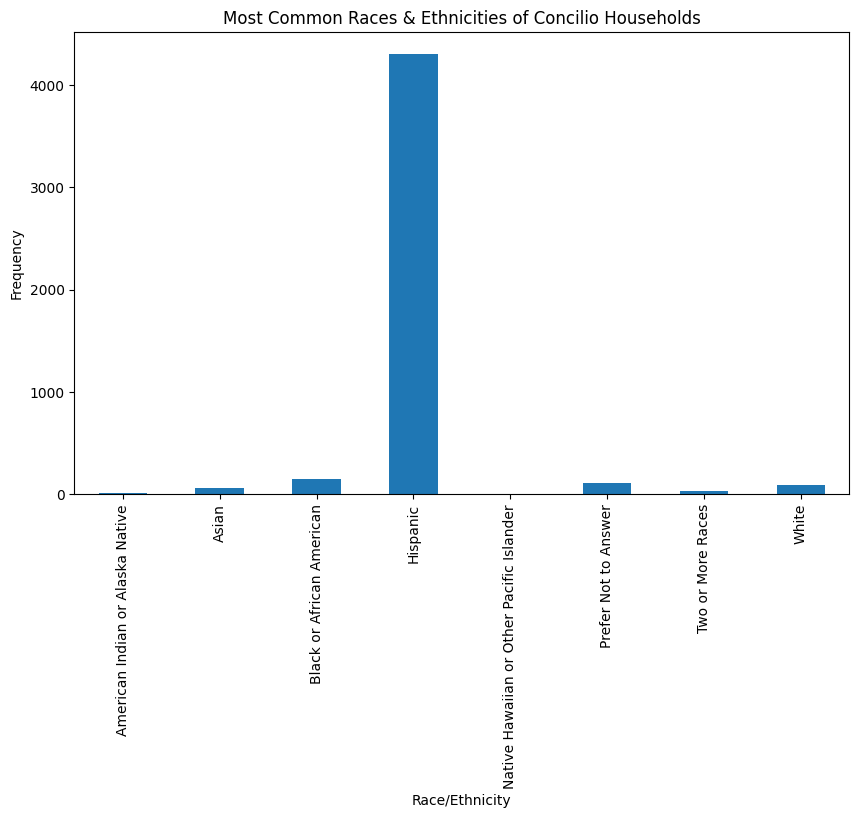

In [14]:
frequency = concData['Race/Ethnicity'].value_counts().drop('African American', errors='ignore').sort_index()
frequency.plot(kind='bar', figsize=(10, 6), title='Most Common Races & Ethnicities of Concilio Households')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Frequency')
plt.show()

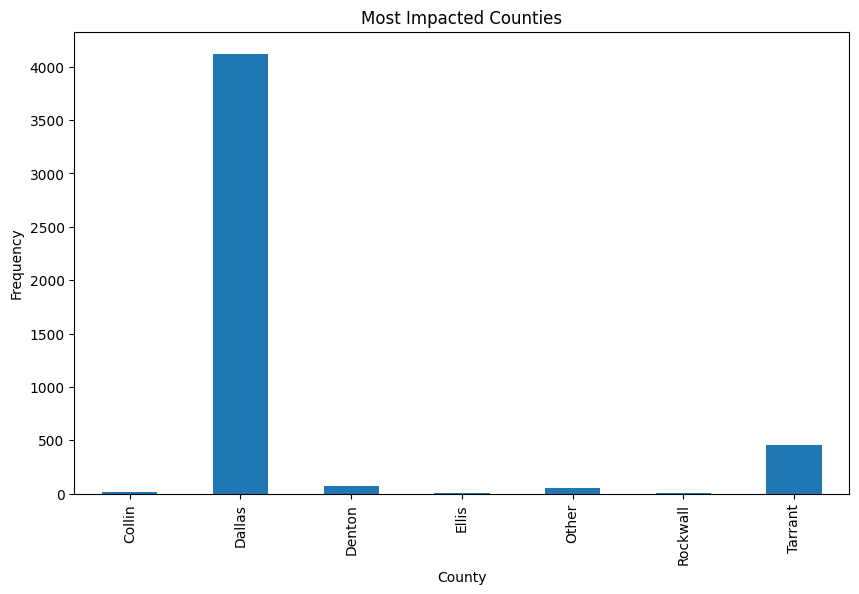

In [ ]:
frequency = concData['Mailing County'].value_counts().drop('Dallas ', errors='ignore').sort_index()
frequency.plot(kind='bar', figsize=(10, 6), title='Most Impacted Counties by Concilio')
plt.xlabel('County')
plt.ylabel('Frequency')
plt.show()

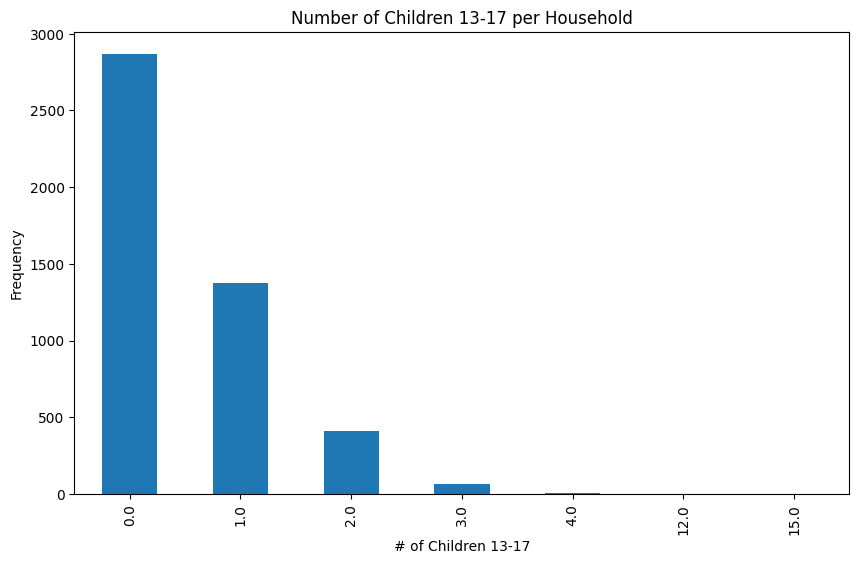

In [17]:
frequency = concData['# of Children 13-17'].value_counts().sort_index()
frequency.plot(kind='bar', figsize=(10, 6), title='Number of Children 13-17 per Household')
plt.xlabel('# of Children 13-17')
plt.ylabel('Frequency')
plt.show()